<a href="https://colab.research.google.com/github/Vaishnavi0620/Car_Price_Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Install libraries

!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Get a dataset
brand,year,kms_driven,fuel,transmission,owners,engine,price
Toyota,2020,35000,Petrol,Automatic,1,1496,850000
Honda,2019,42000,Petrol,Manual,1,1498,720000
Hyundai,2021,20000,Diesel,Manual,1,1396,900000
Maruti,2018,50000,Petrol,Manual,2,1197,550000
Tata,2020,30000,Diesel,Manual,1,1497,700000

In [ ]:
#Load the dataset
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/car_data.csv')

print(df.head())
print(df.columns.tolist())


Empty DataFrame
Columns: [brand,year,kms_driven,fuel,transmission,owners,engine,price
Toyota,2020,35000,Petrol,Automatic,1,1496,850000
Honda,2019,42000,Petrol,Manual,1,1498,720000
Hyundai,2021,20000,Diesel,Manual,1,1396,900000
Maruti,2018,50000,Petrol,Manual,2,1197,550000
Tata,2020,30000,Diesel,Manual,1,1497,700000]
Index: []
['brand,year,kms_driven,fuel,transmission,owners,engine,price\nToyota,2020,35000,Petrol,Automatic,1,1496,850000\nHonda,2019,42000,Petrol,Manual,1,1498,720000\nHyundai,2021,20000,Diesel,Manual,1,1396,900000\nMaruti,2018,50000,Petrol,Manual,2,1197,550000\nTata,2020,30000,Diesel,Manual,1,1497,700000']


In [ ]:
#Check the dataset
print(df.shape)
print(df.info())
print(df.isnull().sum())

(0, 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                              --------------  ----- 
 0   brand,year,kms_driven,fuel,transmission,owners,engine,price
Toyota,2020,35000,Petrol,Automatic,1,1496,850000
Honda,2019,42000,Petrol,Manual,1,1498,720000
Hyundai,2021,20000,Diesel,Manual,1,1396,900000
Maruti,2018,50000,Petrol,Manual,2,1197,550000
Tata,2020

In [ ]:
#Remove missing values
df = df.dropna()

print(df.isnull().sum())

brand,year,kms_driven,fuel,transmission,owners,engine,price\nToyota,2020,35000,Petrol,Automatic,1,1496,850000\nHonda,2019,42000,Petrol,Manual,1,1498,720000\nHyundai,2021,20000,Diesel,Manual,1,1396,900000\nMaruti,2018,50000,Petrol,Manual,2,1197,550000\nTata,2020,30000,Diesel,Manual,1,1497,700000    0
dtype: int64


In [ ]:
print(df.columns)

Index(['brand,year,kms_driven,fuel,transmission,owners,engine,price\nToyota,2020,35000,Petrol,Automatic,1,1496,850000\nHonda,2019,42000,Petrol,Manual,1,1498,720000\nHyundai,2021,20000,Diesel,Manual,1,1396,900000\nMaruti,2018,50000,Petrol,Manual,2,1197,550000\nTata,2020,30000,Diesel,Manual,1,1497,700000'], dtype='object')


In [ ]:
import pandas as pd
from io import StringIO

data = """brand,year,kms_driven,fuel,transmission,owners,engine,price
Toyota,2020,35000,Petrol,Automatic,1,1496,850000
Honda,2019,42000,Petrol,Manual,1,1498,720000
Hyundai,2021,20000,Diesel,Manual,1,1396,900000
Maruti,2018,50000,Petrol,Manual,2,1197,550000
Tata,2020,30000,Diesel,Manual,1,1497,700000"""

df = pd.read_csv(StringIO(data))

print(df)
print("\nColumns:")
print(df.columns.tolist())

     brand  year  kms_driven    fuel transmission  owners  engine   price
0   Toyota  2020       35000  Petrol    Automatic       1    1496  850000
1    Honda  2019       42000  Petrol       Manual       1    1498  720000
2  Hyundai  2021       20000  Diesel       Manual       1    1396  900000
3   Maruti  2018       50000  Petrol       Manual       2    1197  550000
4     Tata  2020       30000  Diesel       Manual       1    1497  700000

Columns:
['brand', 'year', 'kms_driven', 'fuel', 'transmission', 'owners', 'engine', 'price']


In [ ]:
#Separate input and output
X = df.drop('price', axis=1)
y = df['price']

print("X:")
print(X)

print("\ny:")
print(y)

X:
     brand  year  kms_driven    fuel transmission  owners  engine
0   Toyota  2020       35000  Petrol    Automatic       1    1496
1    Honda  2019       42000  Petrol       Manual       1    1498
2  Hyundai  2021       20000  Diesel       Manual       1    1396
3   Maruti  2018       50000  Petrol       Manual       2    1197
4     Tata  2020       30000  Diesel       Manual       1    1497

y:
0    850000
1    720000
2    900000
3    550000
4    700000
Name: price, dtype: int64


In [ ]:
#Identify categorical columns
#Some columns contain text.

categorical_features = [
    "brand",
    "fuel",
    "transmission"
]

In [ ]:
#Numerical columns:
numerical_features = [
    "year",
    "kms_driven",
    "owners",
    "engine"
]

Convert text into numbers
Petrol
Diesel
Automatic
Manual

In [ ]:
#One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


In [ ]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4, 7)
Testing data: (1, 7)


In [ ]:
#Create the AI model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
#Create the complete ML pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [ ]:
#Train the AI model
pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
#Make predictions
y_pred = pipeline.predict(X_test)

print(y_pred[:5])


[706500.]


In [ ]:
#Check model accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 13500.0
R2 Score: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
#Predict the price of a new car
new_car = pd.DataFrame({
    "brand": ["Toyota"],
    "year": [2020],
    "kms_driven": [35000],
    "fuel": ["Petrol"],
    "transmission": ["Automatic"],
    "owners": [1],
    "engine": [1496]
})

In [ ]:
#Predict
predicted_price = pipeline.predict(new_car)

print("Predicted Car Price: ₹", round(predicted_price[0], 2))

Predicted Car Price: ₹ 790500.0


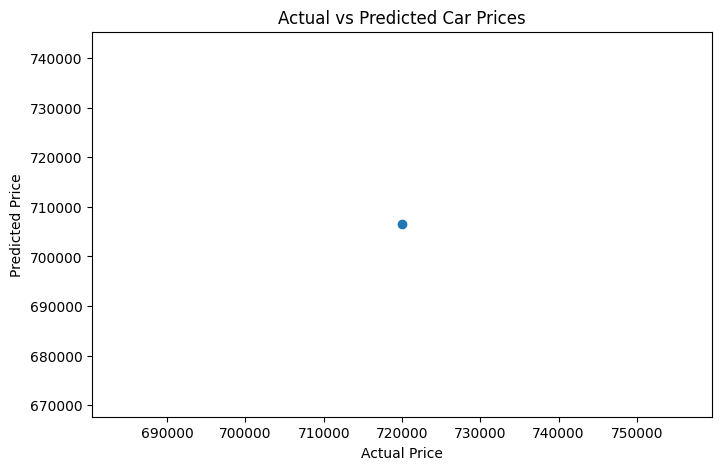

In [ ]:
#Create a simple graph
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# 1. Load dataset
df = pd.read_csv("car_data.csv")


# 2. Remove missing values
df = df.dropna()


# 3. Separate features and target
X = df.drop("price", axis=1)
y = df["price"]


# 4. Define columns
categorical_features = [
    "brand",
    "fuel",
    "transmission"
]

numerical_features = [
    "year",
    "kms_driven",
    "owners",
    "engine"
]


# 5. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# 6. Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


# 7. Create pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


# 8. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 9. Train model
pipeline.fit(X_train, y_train)


# 10. Predict test data
y_pred = pipeline.predict(X_test)


# 11. Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model trained successfully!")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


# 12. New car
new_car = pd.DataFrame({
    "brand": ["Toyota"],
    "year": [2020],
    "kms_driven": [35000],
    "fuel": ["Petrol"],
    "transmission": ["Automatic"],
    "owners": [1],
    "engine": [1496]
})


# 13. Predict new car price
predicted_price = pipeline.predict(new_car)

print("\nPredicted Car Price: ₹", round(predicted_price[0], 2))


# 14. Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()